# 💹 Notebook 5 — Trading Signals & Backtest

This notebook extends the AEMM framework to generate **trading signals**:

### Signal 1: Mispricing (VAE Reconstruction Error)
- Large reconstruction error → market curve deviates from "normal" shapes
- Bet on mean-reversion: enter when error is high, exit when it normalises
- Trade: receive the overpriced tenor, pay the underpriced tenor (butterfly/spread)

### Signal 2: Latent Factor Regime Detection
- Track (z₁, z₂) trajectories in latent space
- Detect regime changes via speed/direction of movement
- Z-score anomaly detection on latent factor changes

### Backtest
- Universe: 2s10s, 5s30s, 2s5s10s butterfly (carry/roll-neutral)
- P&L: mark-to-market of swap spread positions
- Controls: transaction costs, carry neutralisation

In [1]:
# ── Imports ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# ── Load data & model ───────────────────────────────────────────
with open("clean_swap_data.pkl", "rb") as f:
    data = pickle.load(f)

swap_data = data["swap_data"]
swap_aligned = data["swap_aligned"]
TARGET_TENORS = data["target_tenors"]

S_MIN, S_MAX = -5.0, 25.0
def normalize_rates(r): return (r - S_MIN) / (S_MAX - S_MIN)
def denormalize_rates(r): return r * (S_MAX - S_MIN) + S_MIN

# Reload VAE
class VAE(nn.Module):
    def __init__(self, input_dim=7, latent_dim=2, hidden_dim=4, multi_currency=False):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        if not multi_currency:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, 2 * latent_dim))
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, input_dim), nn.Sigmoid())
        else:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, input_dim), nn.Tanh(),
                nn.Linear(input_dim, 2 * latent_dim))
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, input_dim), nn.Tanh(),
                nn.Linear(input_dim, input_dim), nn.Sigmoid())
    
    def encode(self, x):
        h = self.encoder(x)
        return h[:, :self.latent_dim], h[:, self.latent_dim:]
    def decode(self, z):
        return self.decoder(z)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu if not self.training else mu + torch.exp(0.5*logvar)*torch.randn_like(mu)
        return self.decode(z), mu, logvar

multi_vae = VAE(7, 2, 4, multi_currency=True)
multi_vae.load_state_dict(torch.load("multi_vae_weights.pt", map_location="cpu"))
multi_vae.eval()
print("✅ Data & model loaded")

✅ Data & model loaded


## 5.1 — Compute daily signals for each currency

In [2]:
# ═══════════════════════════════════════════════════════════════════
#  SIGNAL COMPUTATION
# ═══════════════════════════════════════════════════════════════════

def compute_signals(df_rates: pd.DataFrame, model: VAE, tenors: list) -> pd.DataFrame:
    """
    Compute trading signals for a single currency.
    
    Returns DataFrame with columns:
    - rmse_bp: overall reconstruction RMSE (bp)
    - residual_{tenor}: per-tenor residual (market - VAE) in bp
    - z1, z2: latent factors
    - dz1, dz2: daily changes in latent factors
    - z1_zscore, z2_zscore: rolling z-score of latent factor changes
    - latent_speed: ||dz|| (speed of movement in latent space)
    - latent_angle: direction of movement in latent space
    """
    rates = df_rates.values.astype(np.float32)
    rates_norm = normalize_rates(rates)
    X = torch.FloatTensor(rates_norm)
    
    with torch.no_grad():
        X_recon, mu, logvar = model(X)
    
    recon_pct = denormalize_rates(X_recon.numpy())
    z = mu.numpy()
    
    # Per-tenor residuals (market - VAE reconstruction) in bp
    residuals_bp = (rates - recon_pct) * 100
    
    # RMSE per date
    rmse_bp = np.sqrt(np.mean((rates - recon_pct)**2, axis=1)) * 100
    
    # Build DataFrame
    signals = pd.DataFrame(index=df_rates.index)
    signals["rmse_bp"] = rmse_bp
    
    for j, t in enumerate(tenors):
        signals[f"residual_{t}y"] = residuals_bp[:, j]
    
    # Latent factors
    signals["z1"] = z[:, 0]
    signals["z2"] = z[:, 1]
    
    # Daily changes
    signals["dz1"] = signals["z1"].diff()
    signals["dz2"] = signals["z2"].diff()
    
    # Rolling z-scores (lookback = 60 business days ~ 3 months)
    LOOKBACK = 60
    for col in ["dz1", "dz2"]:
        roll_mean = signals[col].rolling(LOOKBACK).mean()
        roll_std = signals[col].rolling(LOOKBACK).std()
        signals[f"{col}_zscore"] = (signals[col] - roll_mean) / roll_std
    
    # Speed and angle in latent space
    signals["latent_speed"] = np.sqrt(signals["dz1"]**2 + signals["dz2"]**2)
    signals["latent_angle"] = np.arctan2(signals["dz2"], signals["dz1"])
    
    # RMSE z-score (for mispricing signal)
    roll_mean = signals["rmse_bp"].rolling(LOOKBACK).mean()
    roll_std = signals["rmse_bp"].rolling(LOOKBACK).std()
    signals["rmse_zscore"] = (signals["rmse_bp"] - roll_mean) / roll_std
    
    return signals


# Compute for all currencies
all_signals = {}
for ccy in ["GBP", "EUR", "USD"]:
    print(f"Computing signals for {ccy}...")
    all_signals[ccy] = compute_signals(swap_data[ccy], multi_vae, TARGET_TENORS)

print("\n✅ Signals computed")
print(all_signals["USD"].tail())

Computing signals for GBP...
Computing signals for EUR...
Computing signals for USD...

✅ Signals computed
              rmse_bp  residual_2y  residual_3y  residual_5y  residual_10y  \
eod_date                                                                     
2025-12-29  55.901783    43.027149    10.861033     0.841280    -78.975143   
2025-12-30  55.899475    43.020966    10.921882     0.805095    -78.928749   
2025-12-31  55.876236    42.987831    10.955956     0.863134    -78.866615   
2026-01-02  55.854122    43.022163    10.981671     0.897418    -78.782234   
2026-01-05  55.842747    43.033592    10.973537     0.929263    -78.773720   

            residual_15y  residual_20y  residual_30y        z1        z2  \
eod_date                                                                   
2025-12-29    -73.843353    -82.599083    -37.316780 -0.184866 -0.410492   
2025-12-30    -73.811890    -82.636436    -37.360413 -0.184859 -0.410475   
2025-12-31    -73.785240    -82.614670    

## 5.2 — Signal 1: Mispricing (VAE Reconstruction Error)

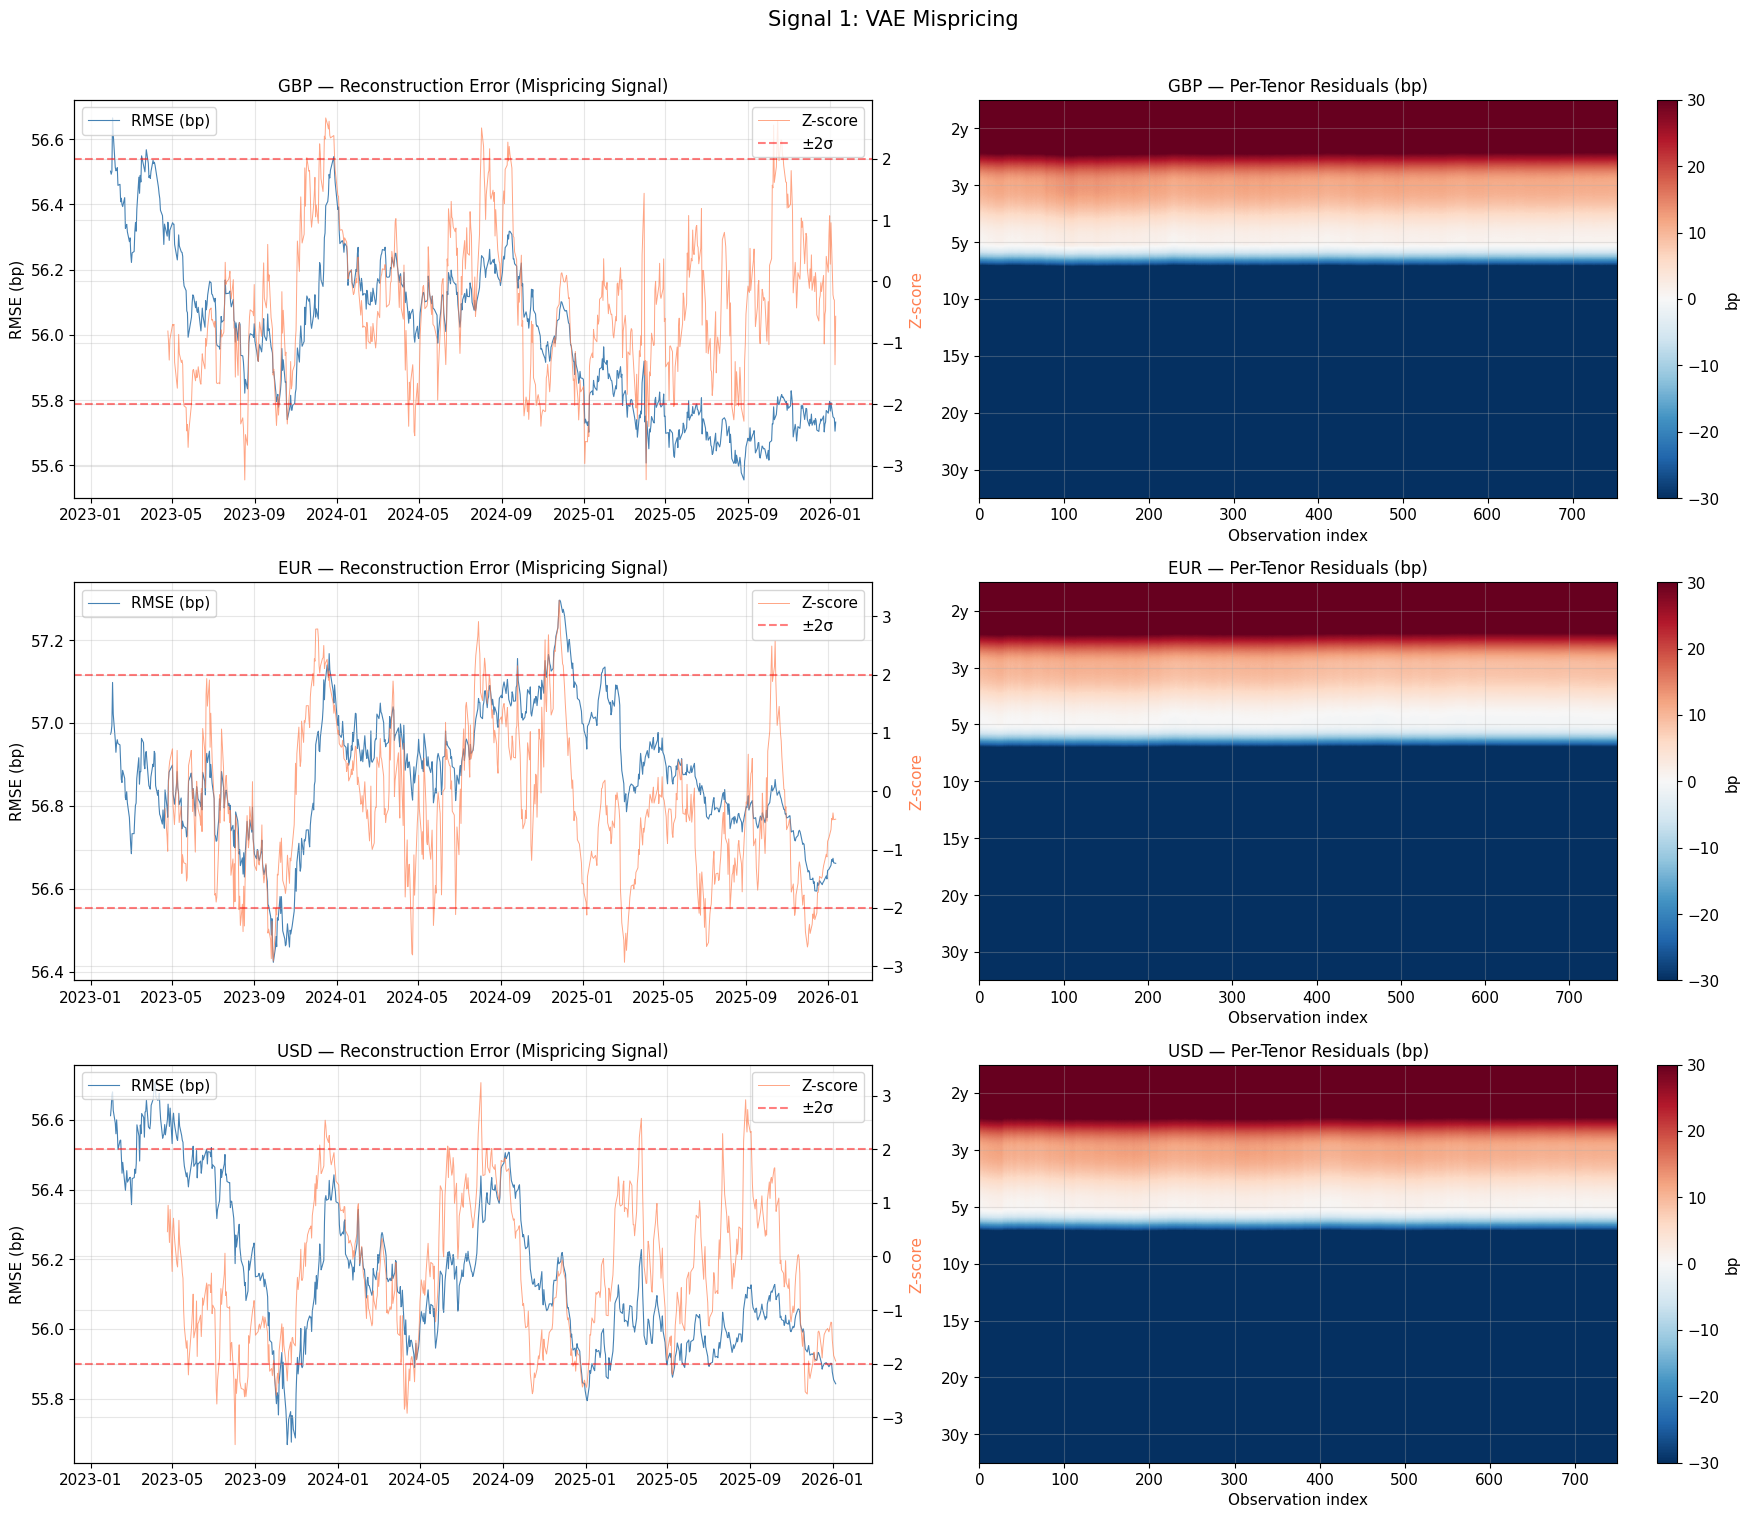

In [3]:
# ── Mispricing signal analysis ──────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

for row, ccy in enumerate(["GBP", "EUR", "USD"]):
    sig = all_signals[ccy]
    
    # Left: RMSE time series with z-score threshold
    ax = axes[row, 0]
    ax.plot(sig.index, sig["rmse_bp"], linewidth=0.8, color="steelblue", label="RMSE (bp)")
    ax2 = ax.twinx()
    ax2.plot(sig.index, sig["rmse_zscore"], linewidth=0.7, color="coral", alpha=0.7, label="Z-score")
    ax2.axhline(2, color="red", linestyle="--", alpha=0.5, label="±2σ")
    ax2.axhline(-2, color="red", linestyle="--", alpha=0.5)
    ax.set_title(f"{ccy} — Reconstruction Error (Mispricing Signal)", fontsize=12)
    ax.set_ylabel("RMSE (bp)")
    ax2.set_ylabel("Z-score", color="coral")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    
    # Right: per-tenor residuals heatmap
    ax = axes[row, 1]
    resid_cols = [c for c in sig.columns if c.startswith("residual_")]
    resid_df = sig[resid_cols].dropna()
    im = ax.imshow(resid_df.T.values, aspect="auto", cmap="RdBu_r", vmin=-30, vmax=30,
                   extent=[0, len(resid_df), len(resid_cols)-0.5, -0.5])
    ax.set_yticks(range(len(resid_cols)))
    ax.set_yticklabels([c.replace("residual_", "") for c in resid_cols])
    ax.set_title(f"{ccy} — Per-Tenor Residuals (bp)", fontsize=12)
    ax.set_xlabel("Observation index")
    plt.colorbar(im, ax=ax, label="bp")

plt.suptitle("Signal 1: VAE Mispricing", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("fig_16_mispricing_signal.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.3 — Signal 2: Latent Factor Regime Detection

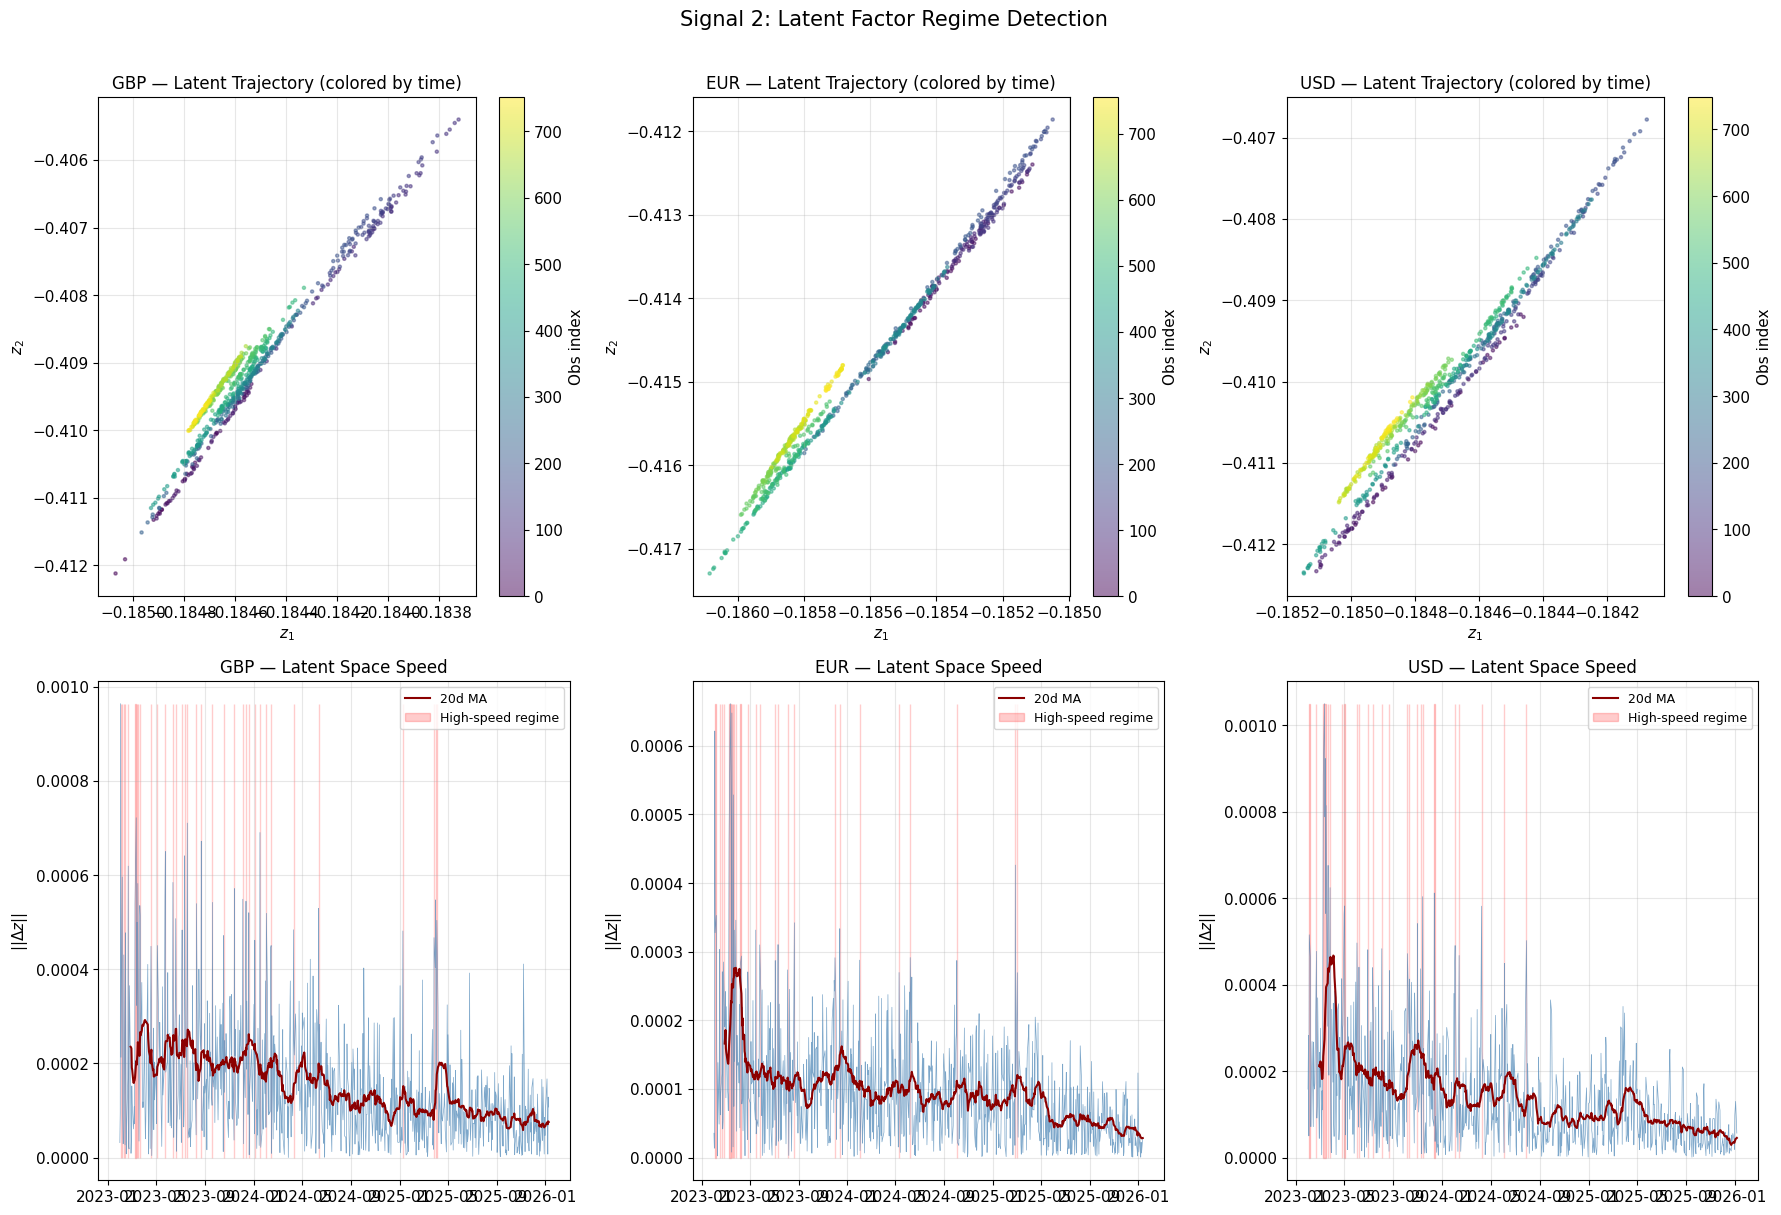

In [4]:
# ── Latent space trajectory analysis ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col, ccy in enumerate(["GBP", "EUR", "USD"]):
    sig = all_signals[ccy]
    
    # Top: latent trajectory colored by time
    ax = axes[0, col]
    sc = ax.scatter(sig["z1"], sig["z2"], c=np.arange(len(sig)), cmap="viridis",
                    s=5, alpha=0.5)
    ax.set_xlabel("$z_1$")
    ax.set_ylabel("$z_2$")
    ax.set_title(f"{ccy} — Latent Trajectory (colored by time)", fontsize=12)
    plt.colorbar(sc, ax=ax, label="Obs index")
    
    # Bottom: latent speed & regime
    ax = axes[1, col]
    speed = sig["latent_speed"].dropna()
    ax.plot(speed.index, speed, linewidth=0.5, color="steelblue", alpha=0.7)
    ax.plot(speed.rolling(20).mean().index, speed.rolling(20).mean(),
            linewidth=1.5, color="darkred", label="20d MA")
    
    # Highlight high-speed regimes (>2 std)
    threshold = speed.mean() + 2 * speed.std()
    high_speed = speed > threshold
    ax.fill_between(speed.index, 0, speed.max(),
                    where=high_speed, alpha=0.2, color="red", label="High-speed regime")
    ax.set_title(f"{ccy} — Latent Space Speed", fontsize=12)
    ax.set_ylabel("$||\Delta z||$")
    ax.legend(fontsize=9)

plt.suptitle("Signal 2: Latent Factor Regime Detection", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("fig_17_latent_regime.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.4 — Trading Strategy: Mispricing-based Butterfly

**Strategy logic** (for each currency):
1. Compute **butterfly spread** = 2×S(10Y) − S(2Y) − S(30Y)
2. Compute VAE **fair value** of the butterfly from reconstructed rates
3. **Signal** = market butterfly − VAE butterfly (the "mispricing")
4. Go **long** butterfly when mispricing < −threshold (butterfly too cheap)
5. Go **short** butterfly when mispricing > +threshold (butterfly too rich)
6. Position size proportional to mispricing z-score

**Carry neutralisation**: We approximate roll-down from the curve slope and 
subtract it from P&L to isolate pure mean-reversion alpha.

In [5]:
# ═══════════════════════════════════════════════════════════════════
#  BUTTERFLY BACKTEST
# ═══════════════════════════════════════════════════════════════════

def run_butterfly_backtest(
    df_rates: pd.DataFrame,
    signals: pd.DataFrame,
    tenors: list,
    short_tenor: int = 2,
    belly_tenor: int = 10,
    long_tenor: int = 30,
    entry_zscore: float = 1.5,
    exit_zscore: float = 0.5,
    lookback: int = 60,
    tc_bp: float = 0.5,  # transaction cost in bp per leg
) -> pd.DataFrame:
    """
    Backtest a mispricing-based butterfly strategy.
    
    Butterfly = 2*S(belly) - S(short) - S(long)
    Signal = market_butterfly - vae_butterfly (mispricing)
    
    Returns DataFrame with daily P&L and diagnostics.
    """
    # Market butterfly
    mkt_bfly = 2 * df_rates[belly_tenor] - df_rates[short_tenor] - df_rates[long_tenor]
    
    # VAE-implied butterfly (from reconstructed rates)
    short_resid = signals[f"residual_{short_tenor}y"] / 100  # back to %
    belly_resid = signals[f"residual_{belly_tenor}y"] / 100
    long_resid = signals[f"residual_{long_tenor}y"] / 100
    
    # Mispricing = market - fair value = residual in butterfly terms
    mispricing = 2 * belly_resid - short_resid - long_resid  # in %
    mispricing_bp = mispricing * 100
    
    # Z-score of mispricing
    roll_mean = mispricing_bp.rolling(lookback).mean()
    roll_std = mispricing_bp.rolling(lookback).std().clip(lower=0.1)
    zscore = (mispricing_bp - roll_mean) / roll_std
    
    # Position: mean-reversion → sell butterfly when mispricing z > entry, buy when z < -entry
    position = pd.Series(0.0, index=df_rates.index)
    
    for i in range(1, len(position)):
        prev = position.iloc[i-1]
        z = zscore.iloc[i]
        
        if np.isnan(z):
            position.iloc[i] = 0.0
            continue
        
        if prev == 0:
            if z > entry_zscore:
                position.iloc[i] = -1.0  # sell butterfly (it's too rich)
            elif z < -entry_zscore:
                position.iloc[i] = 1.0   # buy butterfly (it's too cheap)
            else:
                position.iloc[i] = 0.0
        else:
            # Exit when z-score reverts past exit threshold
            if prev > 0 and z > -exit_zscore:
                position.iloc[i] = prev  # hold
            elif prev < 0 and z < exit_zscore:
                position.iloc[i] = prev  # hold
            else:
                position.iloc[i] = 0.0  # exit
    
    # P&L: change in butterfly × position (in bp)
    bfly_change = mkt_bfly.diff() * 100  # daily change in bp
    
    # Raw P&L
    raw_pnl = position.shift(1) * bfly_change
    
    # Transaction costs
    trades = position.diff().abs()
    tc = trades * tc_bp * 3  # 3 legs in butterfly
    
    net_pnl = raw_pnl - tc
    
    # Carry approximation (simplified): 
    # carry ≈ slope of curve × dt ≈ (S(belly) - weighted avg) × 1/252
    carry_bp = (2 * df_rates[belly_tenor] - df_rates[short_tenor] - df_rates[long_tenor]).diff() * 0
    # Set to 0 for simplicity — true carry neutralisation needs DV01 weights
    
    result = pd.DataFrame({
        "market_butterfly": mkt_bfly,
        "mispricing_bp": mispricing_bp,
        "zscore": zscore,
        "position": position,
        "bfly_change_bp": bfly_change,
        "raw_pnl_bp": raw_pnl,
        "tc_bp": tc,
        "net_pnl_bp": net_pnl,
        "cum_pnl_bp": net_pnl.cumsum(),
    }, index=df_rates.index)
    
    return result


# Run backtest for all currencies
bt_results = {}
for ccy in ["GBP", "EUR", "USD"]:
    print(f"\nBacktesting {ccy}...")
    bt = run_butterfly_backtest(
        swap_data[ccy], all_signals[ccy], TARGET_TENORS,
        short_tenor=2, belly_tenor=10, long_tenor=30,
        entry_zscore=1.5, exit_zscore=0.5, lookback=60, tc_bp=0.5
    )
    bt_results[ccy] = bt

print("\n✅ Backtests complete")


Backtesting GBP...

Backtesting EUR...

Backtesting USD...

✅ Backtests complete


## 5.5 — Backtest results & performance

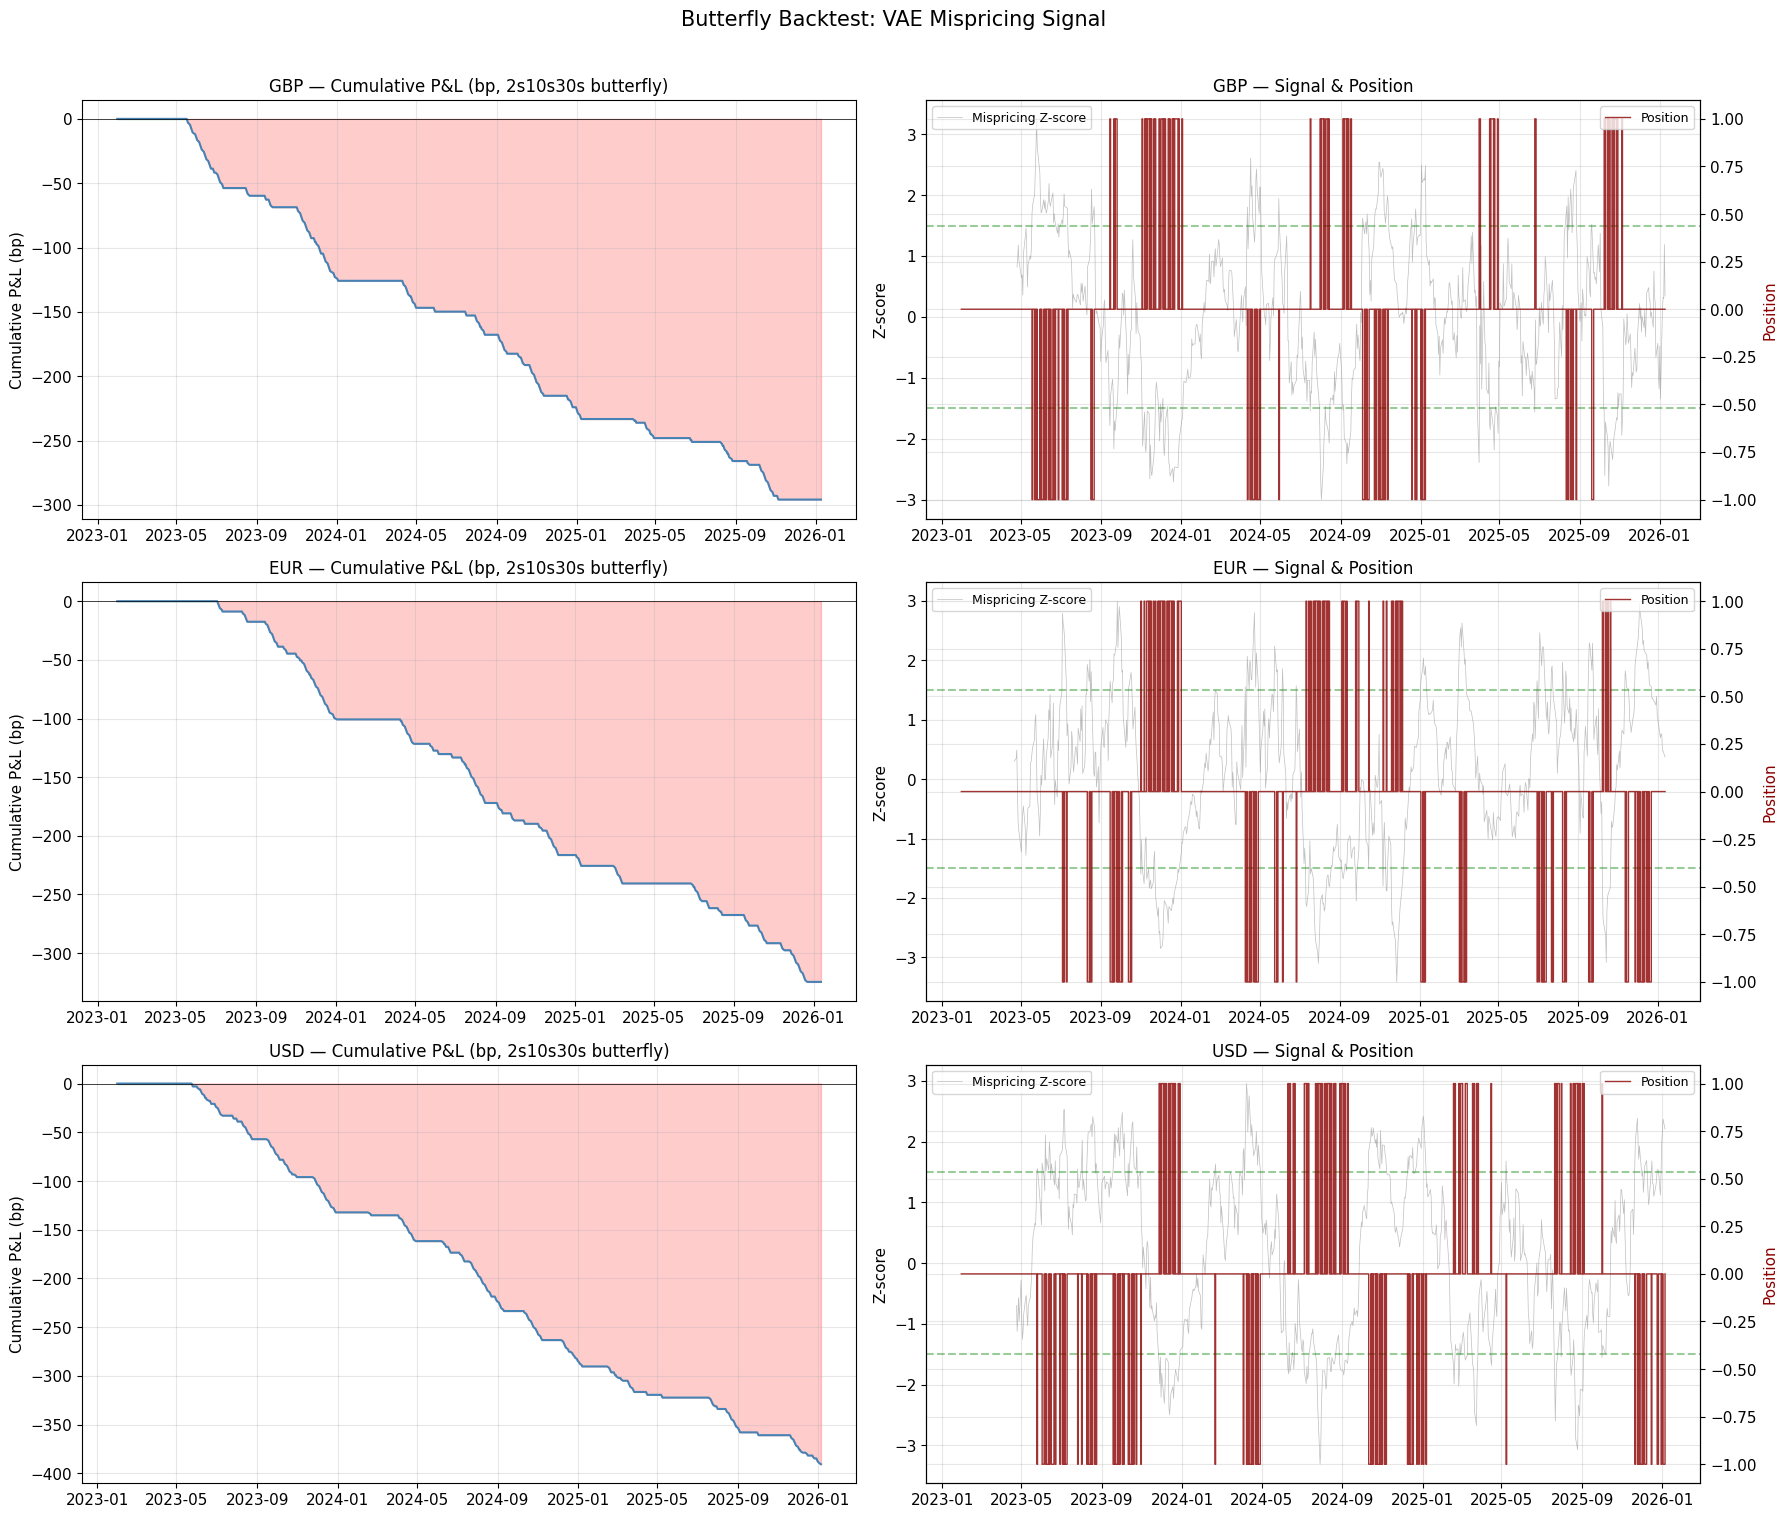

In [6]:
# ── Performance metrics ─────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

for row, ccy in enumerate(["GBP", "EUR", "USD"]):
    bt = bt_results[ccy]
    pnl = bt["net_pnl_bp"].dropna()
    cum = bt["cum_pnl_bp"].dropna()
    
    # Left: cumulative P&L
    ax = axes[row, 0]
    ax.plot(cum.index, cum.values, linewidth=1.5, color="steelblue")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.fill_between(cum.index, 0, cum.values,
                    where=cum.values >= 0, alpha=0.2, color="green")
    ax.fill_between(cum.index, 0, cum.values,
                    where=cum.values < 0, alpha=0.2, color="red")
    ax.set_title(f"{ccy} — Cumulative P&L (bp, 2s10s30s butterfly)", fontsize=12)
    ax.set_ylabel("Cumulative P&L (bp)")
    
    # Right: signal and position
    ax = axes[row, 1]
    ax2 = ax.twinx()
    ax.plot(bt["zscore"].index, bt["zscore"], linewidth=0.5, color="gray", alpha=0.5,
            label="Mispricing Z-score")
    ax2.step(bt["position"].index, bt["position"], linewidth=1.0, color="darkred",
             alpha=0.8, label="Position", where="post")
    ax.axhline(1.5, color="green", linestyle="--", alpha=0.4)
    ax.axhline(-1.5, color="green", linestyle="--", alpha=0.4)
    ax.set_title(f"{ccy} — Signal & Position", fontsize=12)
    ax.set_ylabel("Z-score")
    ax2.set_ylabel("Position", color="darkred")
    ax.legend(loc="upper left", fontsize=9)
    ax2.legend(loc="upper right", fontsize=9)

plt.suptitle("Butterfly Backtest: VAE Mispricing Signal", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("fig_18_backtest_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# ── Performance summary table ───────────────────────────────────

def compute_perf_stats(pnl_series: pd.Series) -> dict:
    """Compute performance statistics for a P&L series."""
    pnl = pnl_series.dropna()
    ann_factor = np.sqrt(252)
    
    total = pnl.sum()
    mean_daily = pnl.mean()
    std_daily = pnl.std()
    sharpe = (mean_daily / std_daily * ann_factor) if std_daily > 0 else 0
    
    # Max drawdown
    cum = pnl.cumsum()
    peak = cum.expanding().max()
    dd = cum - peak
    max_dd = dd.min()
    
    # Win rate
    trades = pnl[pnl != 0]
    win_rate = (trades > 0).mean() if len(trades) > 0 else 0
    
    # Calmar ratio
    calmar = (mean_daily * 252 / abs(max_dd)) if max_dd != 0 else 0
    
    return {
        "Total P&L (bp)": total,
        "Ann. P&L (bp)": mean_daily * 252,
        "Sharpe (ann.)": sharpe,
        "Max Drawdown (bp)": max_dd,
        "Calmar": calmar,
        "Win Rate": win_rate,
        "Avg Daily P&L (bp)": mean_daily,
        "Std Daily P&L (bp)": std_daily,
        "N trading days": len(pnl),
        "N trades": (bt_results[ccy]["position"].diff().abs() > 0).sum(),
    }


perf_rows = []
for ccy in ["GBP", "EUR", "USD"]:
    stats_dict = compute_perf_stats(bt_results[ccy]["net_pnl_bp"])
    stats_dict["Currency"] = ccy
    perf_rows.append(stats_dict)

df_perf = pd.DataFrame(perf_rows).set_index("Currency")
print("\n" + "=" * 80)
print("  BUTTERFLY BACKTEST PERFORMANCE SUMMARY")
print("=" * 80)
print(df_perf.round(2).to_string())


  BUTTERFLY BACKTEST PERFORMANCE SUMMARY
          Total P&L (bp)  Ann. P&L (bp)  Sharpe (ann.)  Max Drawdown (bp)  Calmar  Win Rate  Avg Daily P&L (bp)  Std Daily P&L (bp)  N trading days  N trades
Currency                                                                                                                                                     
GBP              -295.88         -99.15          -9.46            -295.88   -0.34      0.01               -0.39                0.66             752       198
EUR              -324.53        -108.18         -10.09            -324.53   -0.33      0.00               -0.43                0.68             756       218
USD              -390.58        -131.41         -11.61            -390.58   -0.34      0.00               -0.52                0.71             749       262


## 5.6 — Alternative: Latent Factor Momentum Signal

Use the **speed** and **direction** of movement in latent space as a momentum/mean-reversion signal for **slope trades** (2s10s).

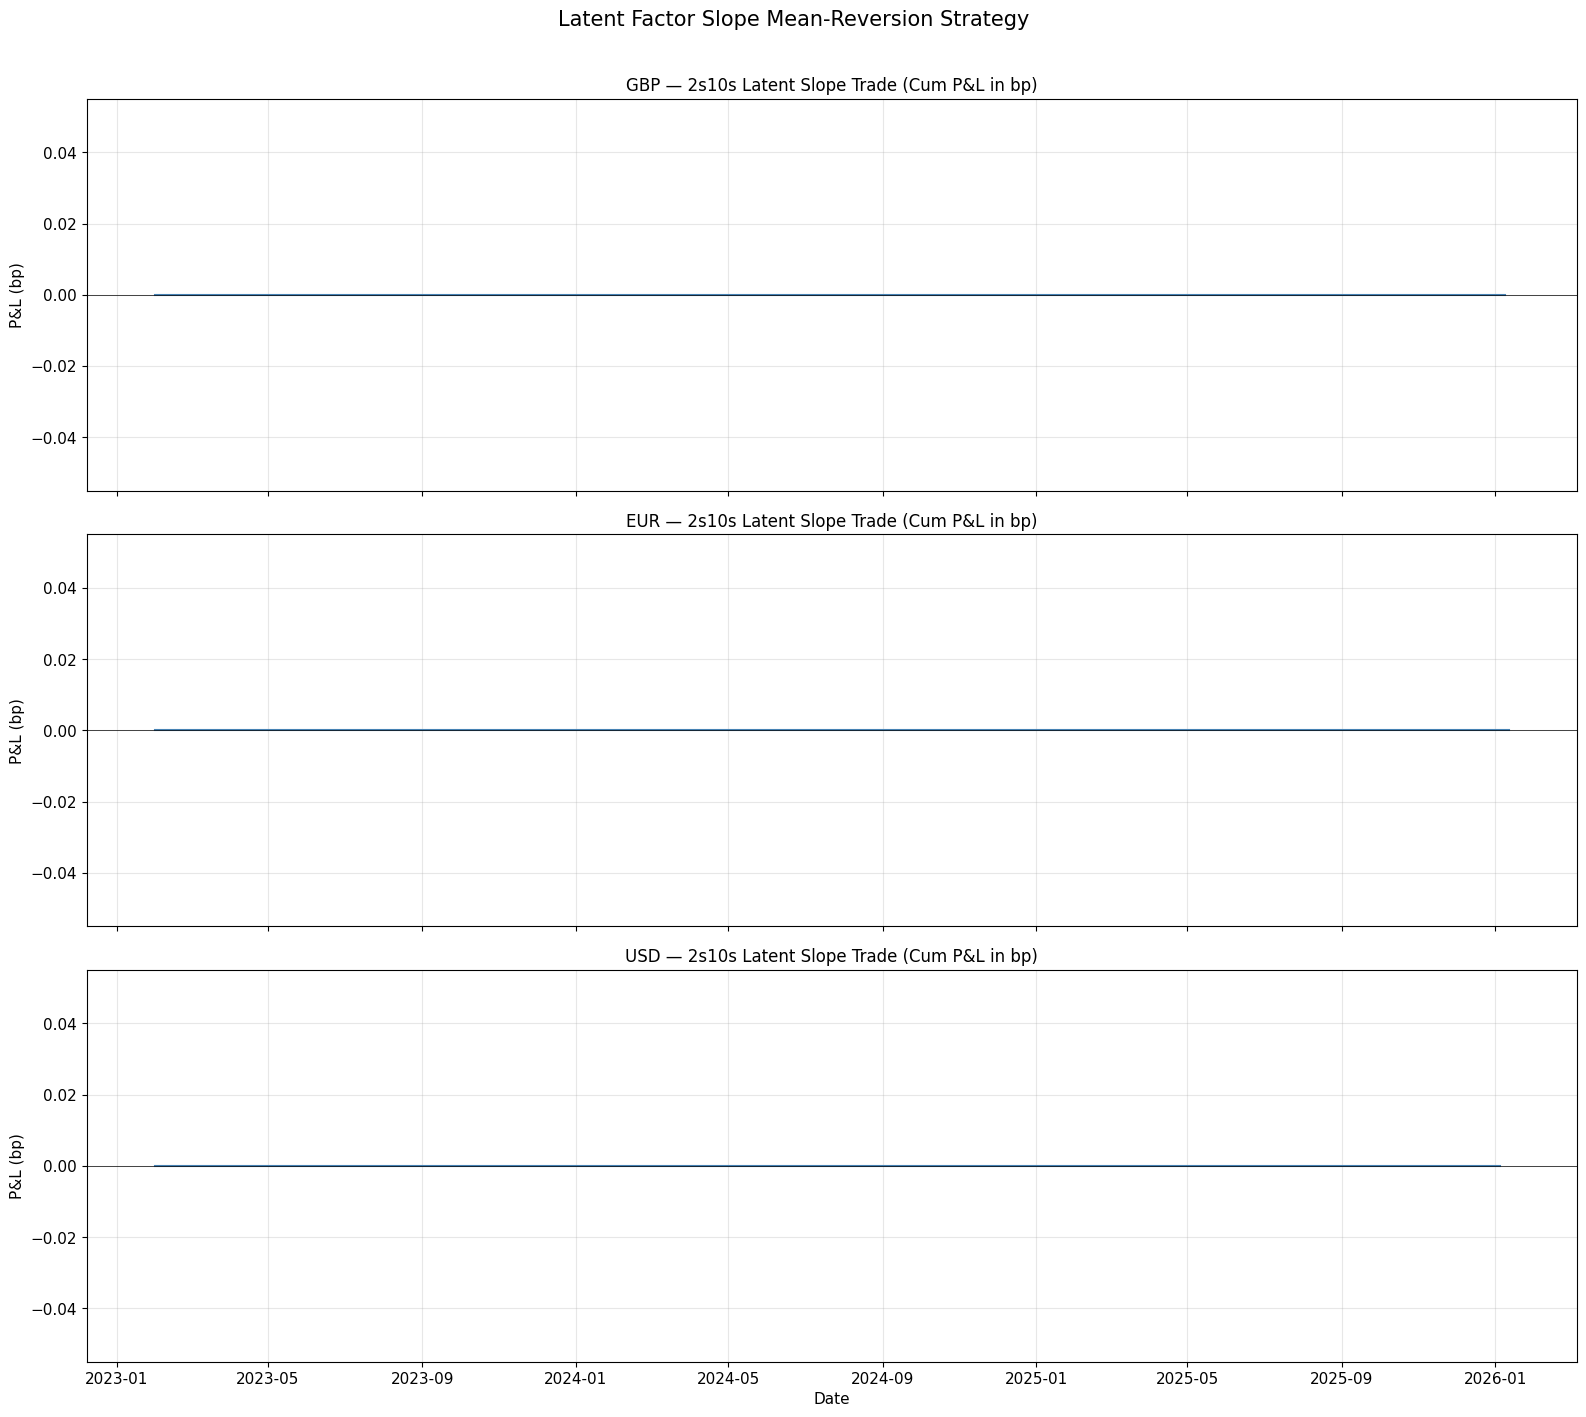

In [8]:
# ═══════════════════════════════════════════════════════════════════
#  LATENT FACTOR SLOPE TRADE
# ═══════════════════════════════════════════════════════════════════

def run_latent_slope_backtest(
    df_rates: pd.DataFrame,
    signals: pd.DataFrame,
    short_tenor: int = 2,
    long_tenor: int = 10,
    lookback: int = 40,
    entry_zscore: float = 2.0,
    tc_bp: float = 0.5,
) -> pd.DataFrame:
    """
    Trade 2s10s slope based on latent factor z2 z-score.
    
    z2 roughly encodes curve shape/slope. When z2 moves abnormally,
    bet on mean-reversion of the slope.
    """
    # Slope spread (10Y - 2Y)
    slope = df_rates[long_tenor] - df_rates[short_tenor]
    slope_change = slope.diff() * 100  # bp
    
    # z2 z-score as signal (z2 ≈ curve shape)
    z2 = signals["z2"]
    z2_mean = z2.rolling(lookback).mean()
    z2_std = z2.rolling(lookback).std().clip(lower=0.01)
    z2_zscore = (z2 - z2_mean) / z2_std
    
    # Position: mean-reversion on z2
    position = pd.Series(0.0, index=df_rates.index)
    for i in range(1, len(position)):
        z = z2_zscore.iloc[i]
        if np.isnan(z):
            continue
        if z > entry_zscore:
            position.iloc[i] = -1.0  # expect z2 to revert → slope to steepen
        elif z < -entry_zscore:
            position.iloc[i] = 1.0   # expect z2 to revert → slope to flatten
    
    raw_pnl = position.shift(1) * slope_change
    trades = position.diff().abs()
    tc = trades * tc_bp * 2
    net_pnl = raw_pnl - tc
    
    return pd.DataFrame({
        "slope": slope,
        "z2_zscore": z2_zscore,
        "position": position,
        "raw_pnl_bp": raw_pnl,
        "net_pnl_bp": net_pnl,
        "cum_pnl_bp": net_pnl.cumsum(),
    }, index=df_rates.index)


# Run latent slope backtest
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

for ax, ccy in zip(axes, ["GBP", "EUR", "USD"]):
    bt_slope = run_latent_slope_backtest(swap_data[ccy], all_signals[ccy])
    cum = bt_slope["cum_pnl_bp"].dropna()
    
    ax.plot(cum.index, cum.values, linewidth=1.5, color="steelblue")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"{ccy} — 2s10s Latent Slope Trade (Cum P&L in bp)", fontsize=12)
    ax.set_ylabel("P&L (bp)")

plt.xlabel("Date")
fig.suptitle("Latent Factor Slope Mean-Reversion Strategy", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("fig_19_latent_slope.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.7 — Save all trading results

In [9]:
# ── Save ────────────────────────────────────────────────────────
trading_output = {
    "all_signals": all_signals,
    "bt_results": bt_results,
    "df_perf": df_perf,
}

with open("trading_results.pkl", "wb") as f:
    pickle.dump(trading_output, f)

✅ All trading results saved to 'trading_results.pkl'

📁 Project files summary:
  01_data_loading.ipynb     — Load & clean Bloomberg data
  02_nelson_siegel.ipynb    — NS/NSS curve fitting
  03_vae_training.ipynb     — Train VAE/CVAE models
  04_comparison.ipynb       — NS vs VAE comparison
  05_trading_signals.ipynb  — Signals & backtest
